In [24]:
%reload_ext autoreload
%autoreload 2

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, PROJECT_ROOT)

from utils.config import FREQ_BANDS, BANDS, METRICS, FMAX, ATLAS_PATH
from utils.io.io_atlas import load_atlas
from utils.io.io_results import (
    load_fc_results,
    group_results_by_subject,
    load_fc_combined_data,
    load_groups,
)
from utils.analysis.spectral.marginal_spectrum import build_net_marginals, build_spectral_features_table
from utils.analysis.functional_connectivity.fc_compute import bin_fcs_by_freq
from utils.analysis.functional_connectivity.fc_aggregate_network import aggregate_to_network_fc
from utils.analysis.functional_connectivity.fc_strength import build_fc_strength_df, build_merged_df
from utils.analysis.spectral.ms_statstical_analysis import (run_network_level_tests)
from utils.analysis.spectral.mixed_models import (
    run_subject_level_tests,
    run_mixed_suite_all,
    run_mixed_model_parametric,
    run_all_networks_parametric,
)
from utils.plot.plot_base import set_mpl_style, add_freq_bands
from utils.plot.plot_diagnostics import plot_linearity_check, plot_residual_diagnostics
from utils.plot.plot_ms_results import (
    print_suite_results,
    print_network_summary_table,
    plot_all_networks_summary,
)

sns.set_theme(context="paper", style="white", font_scale=1.0)
set_mpl_style()

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS  (frequency bands, bands list, metrics, etc. come from utils.config)
# ─────────────────────────────────────────────────────────────────────────────

RES_DIR = "/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/fc"

---
## Section 1: Marginal Spectrum Visualization

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — MARGINAL SPECTRUM VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

# Load atlas and subject data
roi_to_net, n_networks, net_names_21 = load_atlas(ATLAS_PATH)
results       = load_fc_results(RES_DIR)
subjects_dict = group_results_by_subject(results)
groups        = load_groups(subjects_dict)

# Compute marginal Hilbert spectra for all subjects and all networks
net_marginals, freqs_ref = build_net_marginals(
    subjects_dict, groups, roi_to_net, n_networks
)

print(f"Loaded {len(subjects_dict)} subjects: "
      f"{sum(g == 'MDD' for g in groups.values())} MDD, "
      f"{sum(g == 'HC' for g in groups.values())} HC")

[Load] Loaded 165 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/fc
Loaded 42 subjects: 21 MDD, 21 HC


In [29]:
# Plot per-network marginal spectra: MDD vs HC
def add_band_labels(ax, fontsize=8):
    """Add frequency band name labels at the top of the axes."""
    for band, (fmin, fmax) in FREQ_BANDS.items():
        if band == "Whole":
            continue
        x = 0.5 * (fmin + fmax)
        ax.text(
            x, 0.98, band,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=fontsize, rotation=90,
        )

FIGSIZE = (6.8, 3.2)

# for net_name in net_names_21:
#     net_idx = net_names_21.index(net_name)

#     mdd_arr = np.vstack([H for _, H in net_marginals[net_idx]["MDD"]])
#     hc_arr  = np.vstack([H for _, H in net_marginals[net_idx]["HC"]])

#     mdd_mean = mdd_arr.mean(axis=0)
#     hc_mean  = hc_arr.mean(axis=0)
#     mdd_se   = mdd_arr.std(axis=0, ddof=1) / np.sqrt(mdd_arr.shape[0])
#     hc_se    = hc_arr.std(axis=0, ddof=1) / np.sqrt(hc_arr.shape[0])

#     fig, ax = plt.subplots(figsize=FIGSIZE)
#     add_freq_bands(ax, alpha=0.20)

#     ax.plot(freqs_ref, mdd_mean, label="MDD", color="red")
#     ax.fill_between(freqs_ref, mdd_mean - mdd_se, mdd_mean + mdd_se, color="red", alpha=0.2)
#     ax.plot(freqs_ref, hc_mean, label="HC", color="blue")
#     ax.fill_between(freqs_ref, hc_mean - hc_se, hc_mean + hc_se, color="blue", alpha=0.2)

#     add_band_labels(ax)
#     ax.set_xlim(0.0, FMAX)
#     ax.set_ylim(bottom=0)
#     ax.set_xlabel("Frequency (Hz)")
#     ax.set_ylabel("Marginal amplitude")
#     ax.set_title(f"Marginal Hilbert Spectrum — {net_name}")
#     ax.legend(frameon=False)
#     sns.despine(ax=ax)
#     fig.tight_layout()
#     plt.show()

---
## Section 2: Group Comparison

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — GROUP COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

# Build spectral feature table
df_spec = build_spectral_features_table(
    net_marginals, freqs_ref, FREQ_BANDS, net_names_21
)

# Subject-level permutation tests
# Each value is the median across networks per subject, so subjects are independent.
subject_res = run_subject_level_tests(
    df_spec,
    metrics=[
        "rel_band_amp", "band_entropy", "band_centroid",
        "band_amp", "total_amp", "total_entropy", "total_centroid",
    ],
    bands=BANDS,
    agg="median",
    n_perm=20000,
    seed=1,
)
print("\n=== Subject-level global tests ===")
print(subject_res[[
    "metric", "band", "mean_MDD", "mean_HC", "diff_MDD_minus_HC",
    "p_perm", "q_fdr_metricwise", "cohen_d", "hedges_g", "n_MDD", "n_HC",
]].to_string(index=False, float_format=lambda x: f"{x:.4g}"))


=== Subject-level global tests ===
        metric   band  mean_MDD  mean_HC  diff_MDD_minus_HC  p_perm  q_fdr_metricwise  cohen_d  hedges_g  n_MDD  n_HC
      band_amp Slow-4     27.12    35.87             -8.751  0.0377            0.1155  -0.5568   -0.5462     21    21
      band_amp  Whole     54.23    67.69             -13.46  0.0462            0.1155  -0.5341    -0.524     21    21
      band_amp Slow-2     14.13     17.5             -3.373  0.1866             0.311  -0.3063   -0.3006     21    21
      band_amp Slow-5     18.77    21.27             -2.504  0.2511            0.3139  -0.2155   -0.2114     21    21
      band_amp Slow-3      22.7    21.62              1.081  0.6462            0.6462    0.113    0.1109     21    21
 band_centroid Slow-5   0.01909  0.02059          -0.001496  0.0081            0.0405  -0.7569   -0.7426     21    21
 band_centroid  Whole   0.04319   0.0448          -0.001612  0.1942            0.4856  -0.2665   -0.2615     21    21
 band_centroid Slow-

In [31]:
# Network-level permutation tests
# For each (network, band, metric): compare MDD vs HC independently.
# Independence holds: one observation per subject per network (no pooling).
network_res = run_network_level_tests(
    df_spec,
    metrics=["band_amp", "rel_band_amp", "band_centroid"],
    bands=[b for b in BANDS if b != "Whole"],
    n_perm=10000,
    seed=1,
)
significant = network_res[network_res["p_fdr"] < 0.05].sort_values("p_fdr")
print(f"\n=== Network-level tests: {len(significant)} significant results (FDR < 0.05) ===")
if len(significant) > 0:
    print(significant[[
        "network", "metric", "band", "mean_MDD", "mean_HC",
        "diff", "p_perm", "p_fdr", "cohen_d", "hedges_g",
    ]].to_string(index=False, float_format=lambda x: f"{x:.4g}"))
else:
    print("No significant results after FDR correction.")


=== Network-level tests: 21 significant results (FDR < 0.05) ===
     network        metric   band  mean_MDD  mean_HC      diff   p_perm   p_fdr  cohen_d  hedges_g
       ContC band_centroid Slow-5   0.01929  0.02083 -0.001538 0.005099 0.01706  -0.8209   -0.8054
    DefaultC band_centroid Slow-5   0.01906  0.02071 -0.001656   0.0035 0.01706  -0.8775    -0.861
     SomMotA band_centroid Slow-5   0.01899  0.02075 -0.001762   0.0042 0.01706  -0.8298   -0.8142
     SomMotB band_centroid Slow-5     0.019  0.02067 -0.001664 0.005799 0.01706  -0.8017   -0.7866
SalVentAttnA band_centroid Slow-5   0.01906  0.02073 -0.001672   0.0049 0.01706  -0.8148   -0.7995
SalVentAttnB band_centroid Slow-5   0.01918  0.02074 -0.001552 0.006199 0.01706  -0.7719   -0.7574
   DorsAttnB band_centroid Slow-5   0.01908  0.02084 -0.001763   0.0041 0.01706  -0.8276    -0.812
    Thalamus band_centroid Slow-5   0.01912  0.02049 -0.001368 0.006499 0.01706  -0.7766   -0.7619
     LimbicA band_centroid Slow-5   0.01871

---
## Section 3: FC–Amplitude Coupling

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — FC–AMPLITUDE COUPLING
# ─────────────────────────────────────────────────────────────────────────────

# Load combined FC data and prepare frequency-binned matrices
subjects_combined, fcs_by_imf, groups, freqs_by_imf = load_fc_combined_data(RES_DIR)

freq_bands_fc = {k: v for k, v in FREQ_BANDS.items() if k != "Whole"}
fcs_by_band   = bin_fcs_by_freq(subjects_combined, freq_bands_fc)
fcs_by_band["Whole"] = {s: fcs_by_imf["whole"][s] for s in fcs_by_imf["whole"]}
fcs_by_band   = OrderedDict(
    (k, fcs_by_band[k])
    for k in ["Whole", "Slow-5", "Slow-4", "Slow-3", "Slow-2"]
    if k in fcs_by_band
)

binned_netfcs = {
    band: {
        s: aggregate_to_network_fc(fc, roi_to_net, n_networks)
        for s, fc in subj_dict.items()
    }
    for band, subj_dict in fcs_by_band.items()
}

z_binned_netfcs = {
    band: {
        s: np.arctanh(np.clip(fc, -0.999999, 0.999999))
        for s, fc in subj_fcs.items()
    }
    for band, subj_fcs in binned_netfcs.items()
}

df_fc         = build_fc_strength_df(z_binned_netfcs, groups, net_names_21, BANDS)
df_merged_amp = build_merged_df(df_fc, df_spec, "band_amp")

[Load] Loaded 165 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/fc


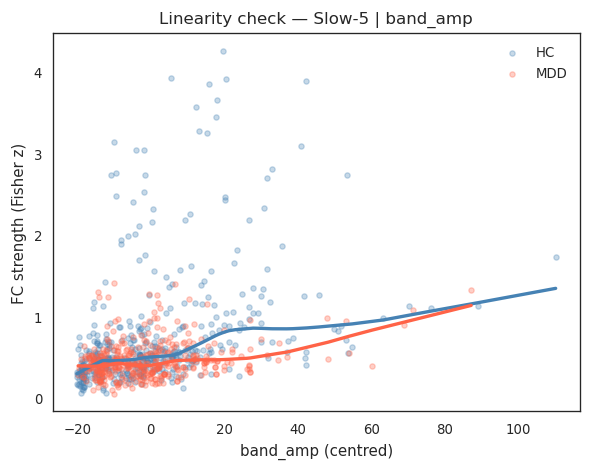

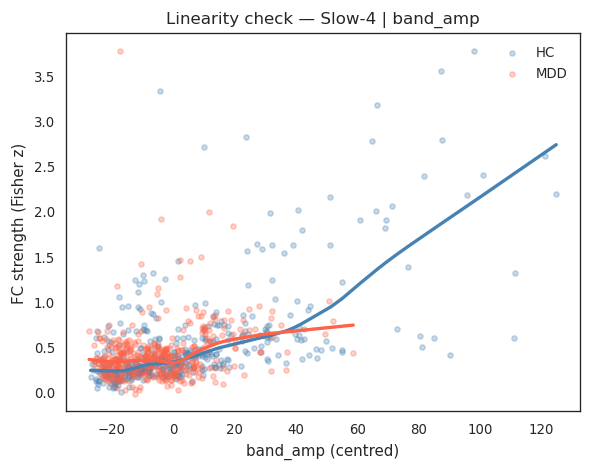

  Fitting band_amp | Slow-5 ...
  Fitting band_amp | Slow-4 ...
  Fitting band_amp | Slow-3 ...
  Fitting band_amp | Slow-2 ...
  Fitting band_amp | Whole ...
  Fitting rel_band_amp | Slow-5 ...
  Fitting rel_band_amp | Slow-4 ...
  Fitting rel_band_amp | Slow-3 ...
  Fitting rel_band_amp | Slow-2 ...
  Fitting rel_band_amp | Whole ...
  Fitting total_amp | Slow-5 ...
  Fitting total_amp | Slow-4 ...
  Fitting total_amp | Slow-3 ...
  Fitting total_amp | Slow-2 ...
  Fitting total_amp | Whole ...

=== Mixed-model suite results ===
      metric   band  n_obs  n_subjects  beta_spec    p_spec  q_fdr_coupling  sig_coupling  beta_group  p_group  beta_group_adj  p_group_adj  beta_interaction  p_interaction  q_fdr_interaction  sig_interaction  AIC_coupling  AIC_additive  AIC_interact
    band_amp Slow-2    525          25   -0.01157     0.472           0.472         False     0.03765    0.229         0.01849       0.4401           0.02844         0.3732             0.3732            False    

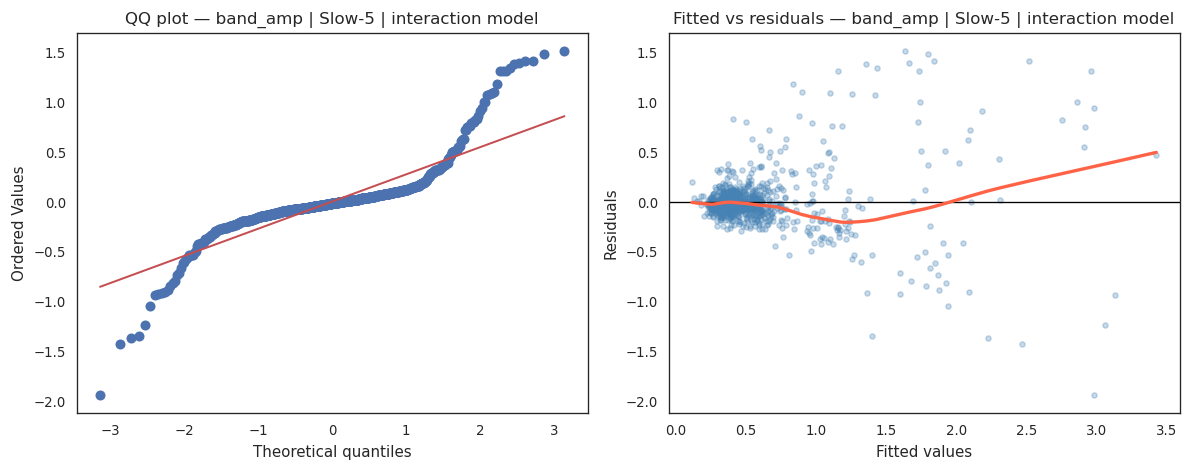


All-network summary | Slow-5 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Striatum          0.132   0.011**    -0.081   0.026**    -0.068   0.032**     16.3       YES
  LimbicB           0.127   0.081      -0.244   0.000**    -0.237   0.001**      3.0       YES
  TempPar           0.277   0.003**    -0.353   0.000**    -0.343   0.086        2.8       YES
  SomMotB           0.414   0.000**    -0.505   0.052*    -0.492   0.040**      2.7       YES
  Thalamus          0.276   0.041**    -0.264   0.020**    -0.260   0.007**      1.4       YES
  ContB             0.104   0.060      -0.175   0.022**    -0.175   0.011**      0.2       YES
  Cerebellum        0.455   0.000**    -0.510   0.001**    -0.512   0.000**     -0.4       YES
  MTL               0.241   0.000**    -0.224   0.098      -0.225   0.094       -0.5       YES
  SomMotA      

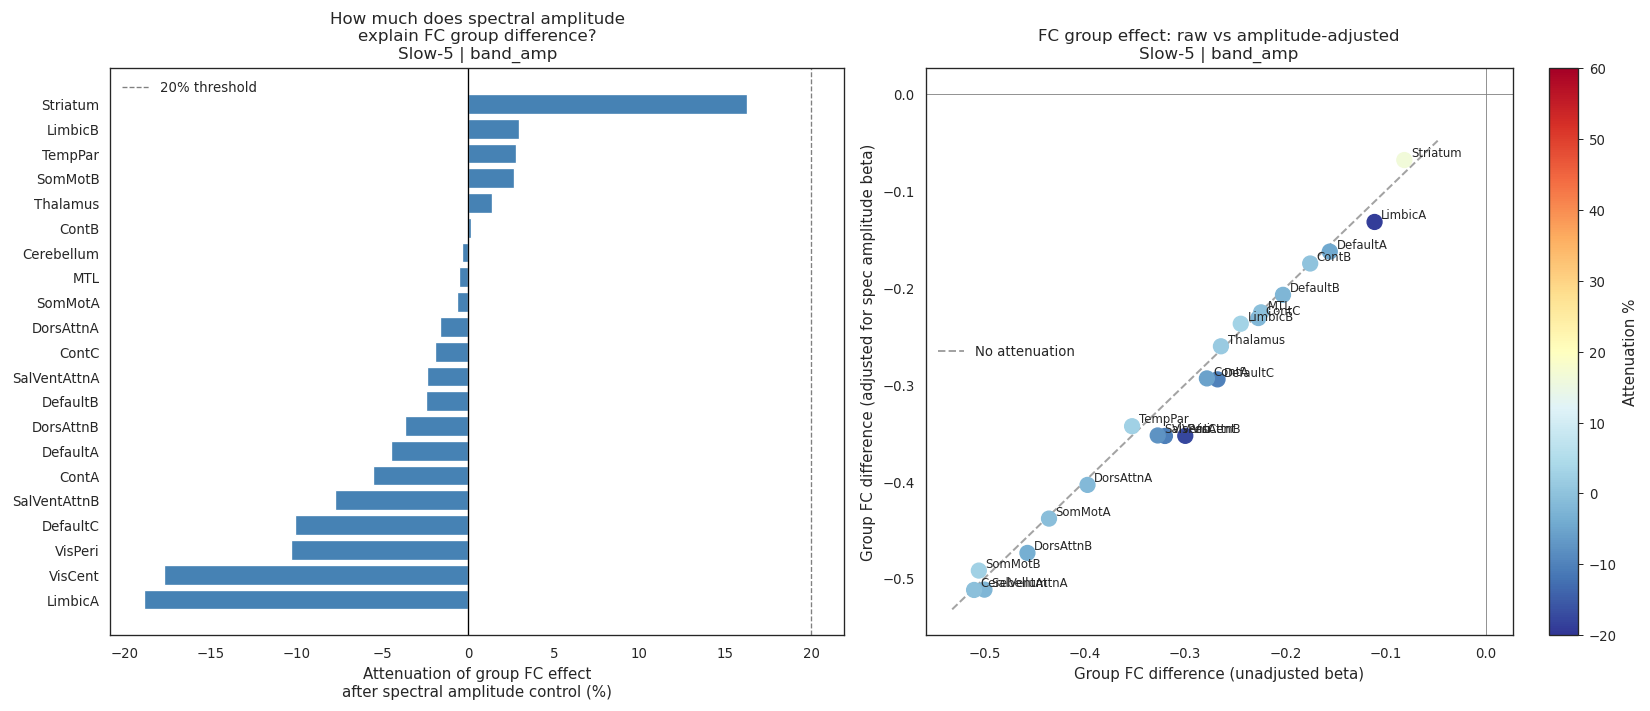


All-network summary | Slow-4 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  ContA             0.445   0.000**    -0.032   0.709       0.062   0.956      295.5       YES
  ContB             0.586   0.000**    -0.069   0.436       0.069   0.956      199.3       YES
  Striatum          0.274   0.000**    -0.047   0.472       0.022   0.956      146.7       YES
  Cerebellum        0.805   0.000**    -0.164   0.290       0.054   0.956      132.8       YES
  LimbicA           0.130   0.013**    -0.005   0.839       0.002   0.956      128.6       YES
  MTL               0.097   0.084      -0.014   0.472       0.004   0.956      125.9       YES
  ContC             0.548   0.000**    -0.137   0.436       0.034   0.956      125.1       YES
  DorsAttnA         0.473   0.000**    -0.120   0.436       0.025   0.956      120.8       YES
  DefaultA    

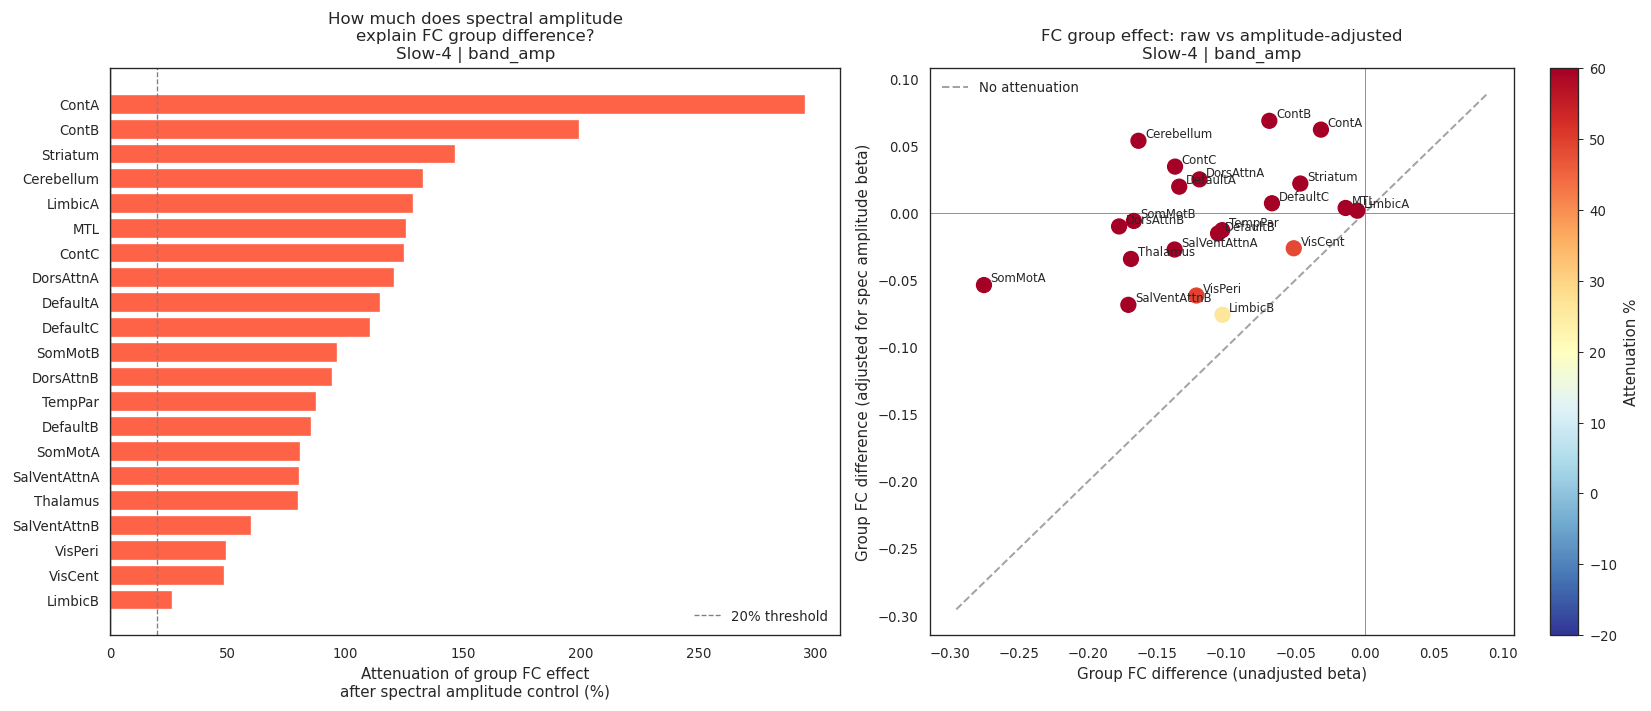


All-network summary | Slow-3 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  LimbicB           0.143   0.017**     0.030   0.113       0.008   0.697       73.5       YES
  Cerebellum        0.830   0.000**     0.295   0.098       0.115   0.504       61.0       YES
  LimbicA           0.359   0.000**     0.172   0.000**     0.085   0.358       50.7       YES
  SalVentAttnB      0.150   0.050*     0.058   0.284       0.040   0.426       31.7       YES
  DefaultB          0.172   0.003**     0.083   0.000**     0.064   0.358       22.8       YES
  VisCent           0.425   0.002**     0.194   0.167       0.156   0.264       20.0       YES
  Thalamus          0.165   0.000**     0.059   0.167       0.048   0.358       18.7       YES
  ContB             0.175   0.040**     0.089   0.000**     0.076   0.224       14.7       YES
  TempPar      

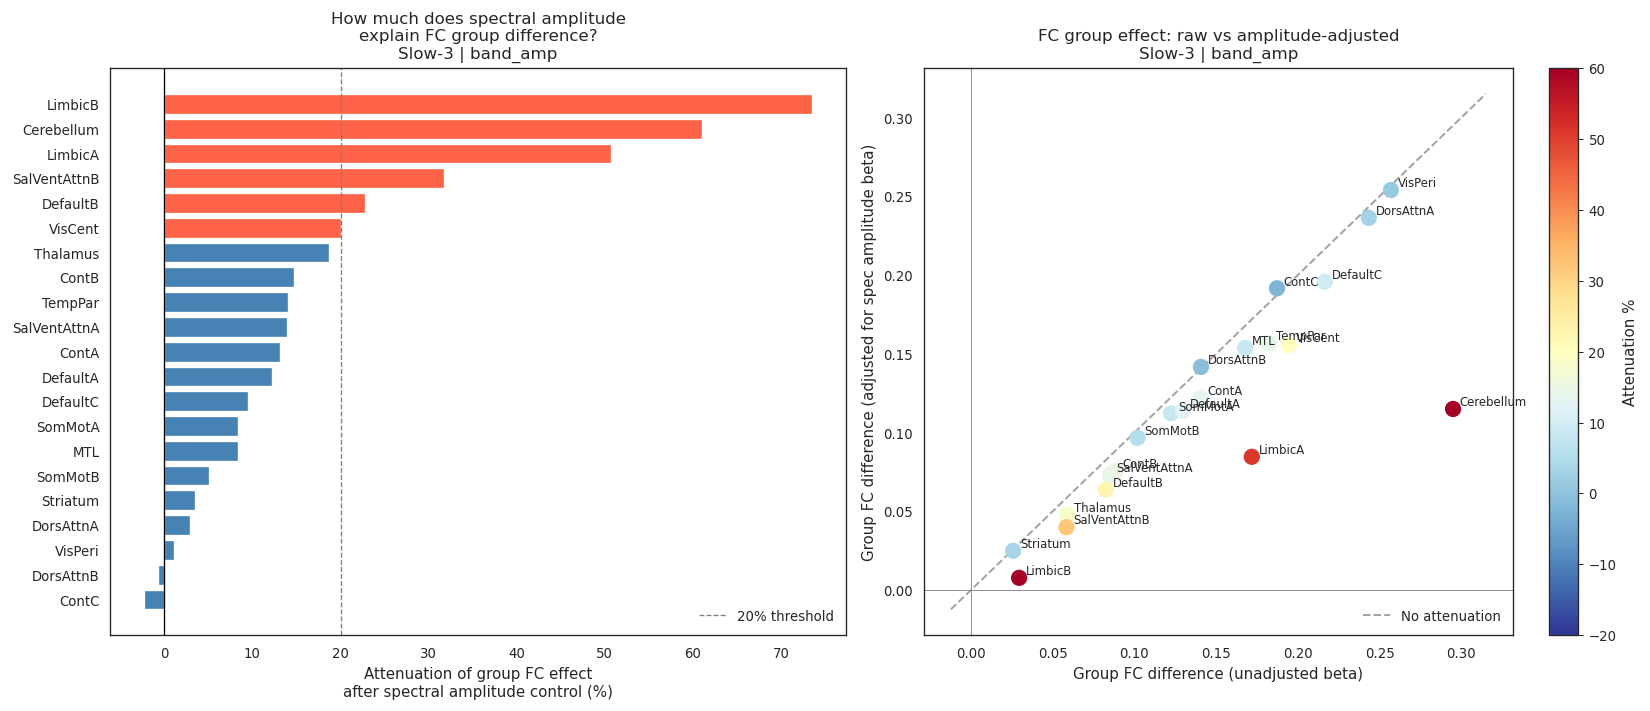


All-network summary | Slow-2 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Thalamus          0.055   0.519      -0.004   0.924       0.002   0.939      155.6        no
  Cerebellum        0.315   0.000**     0.114   0.005**     0.069   0.437       39.6       YES
  Striatum         -0.003   0.925       0.002   0.952       0.001   0.939       19.1        no
  SomMotA          -0.056   0.354       0.018   0.254       0.015   0.210       16.1        no
  LimbicA           0.111   0.000**     0.024   0.256       0.023   0.317        5.2       YES
  VisCent           0.068   0.318       0.057   0.045**     0.055   0.144        3.1        no
  ContC            -0.035   0.606       0.064   0.001**     0.064   0.061*      0.7        no
  VisPeri           0.053   0.679       0.079   0.254       0.080   0.217       -0.4        no
  TempPar      

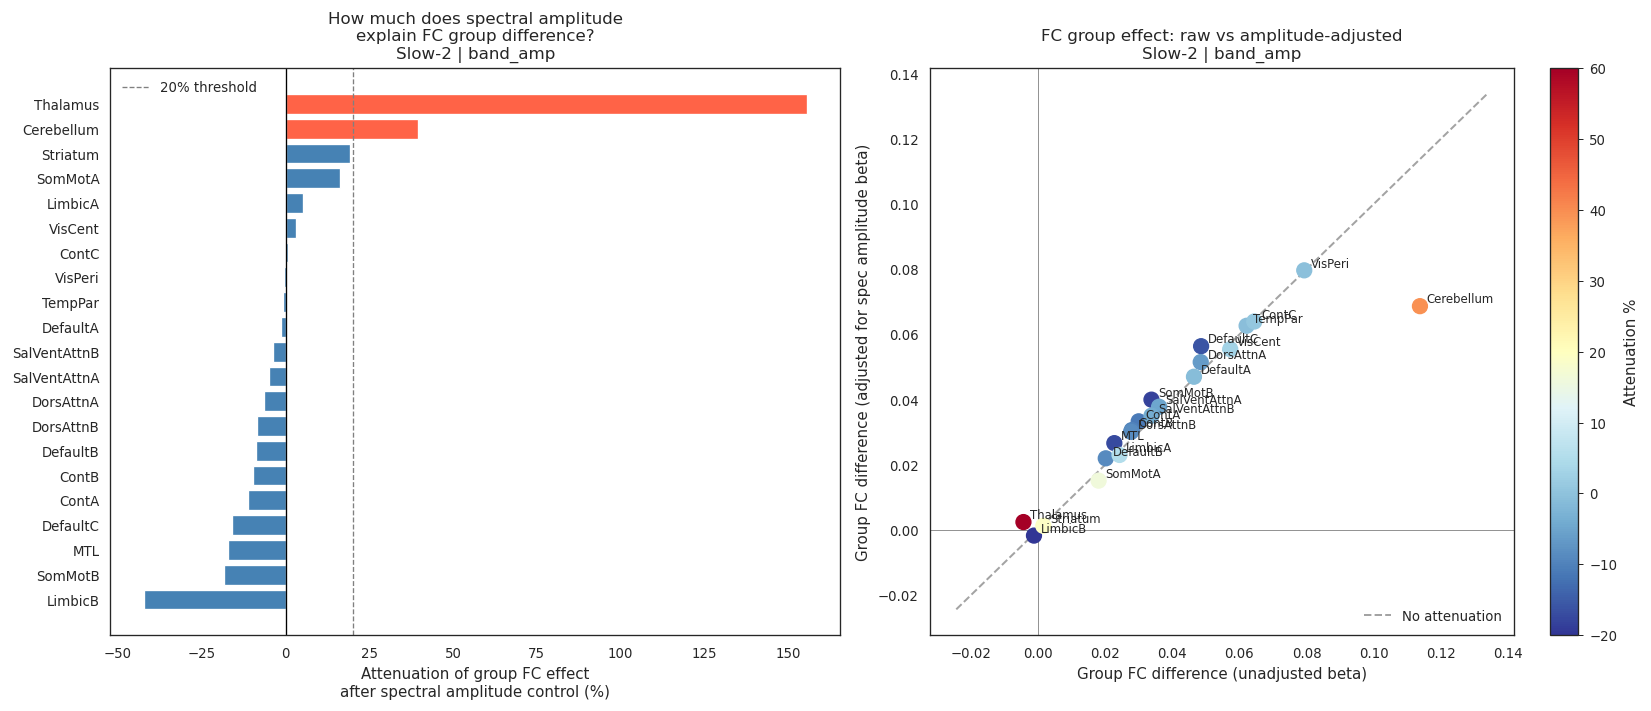


All-network summary | Whole | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Striatum          0.183   0.001**    -0.080   0.074      -0.049   0.263       39.0       YES
  Thalamus          0.167   0.797      -0.205   0.062*    -0.187   0.086*      8.9        no
  MTL               0.081   0.955      -0.102   0.074      -0.097   0.119        5.8        no
  SomMotB           0.145   0.955      -0.318   0.021**    -0.303   0.238        4.8        no
  Cerebellum        0.140   0.955      -0.318   0.144      -0.308   0.206        3.3        no
  LimbicA          -0.034   0.955      -0.065   0.043**    -0.063   0.061*      3.1        no
  SalVentAttnB      0.046   0.955      -0.297   0.043**    -0.297   0.061*      0.2        no
  VisCent          -0.098   0.955      -0.314   0.000**    -0.315   0.035**     -0.3        no
  VisPeri          

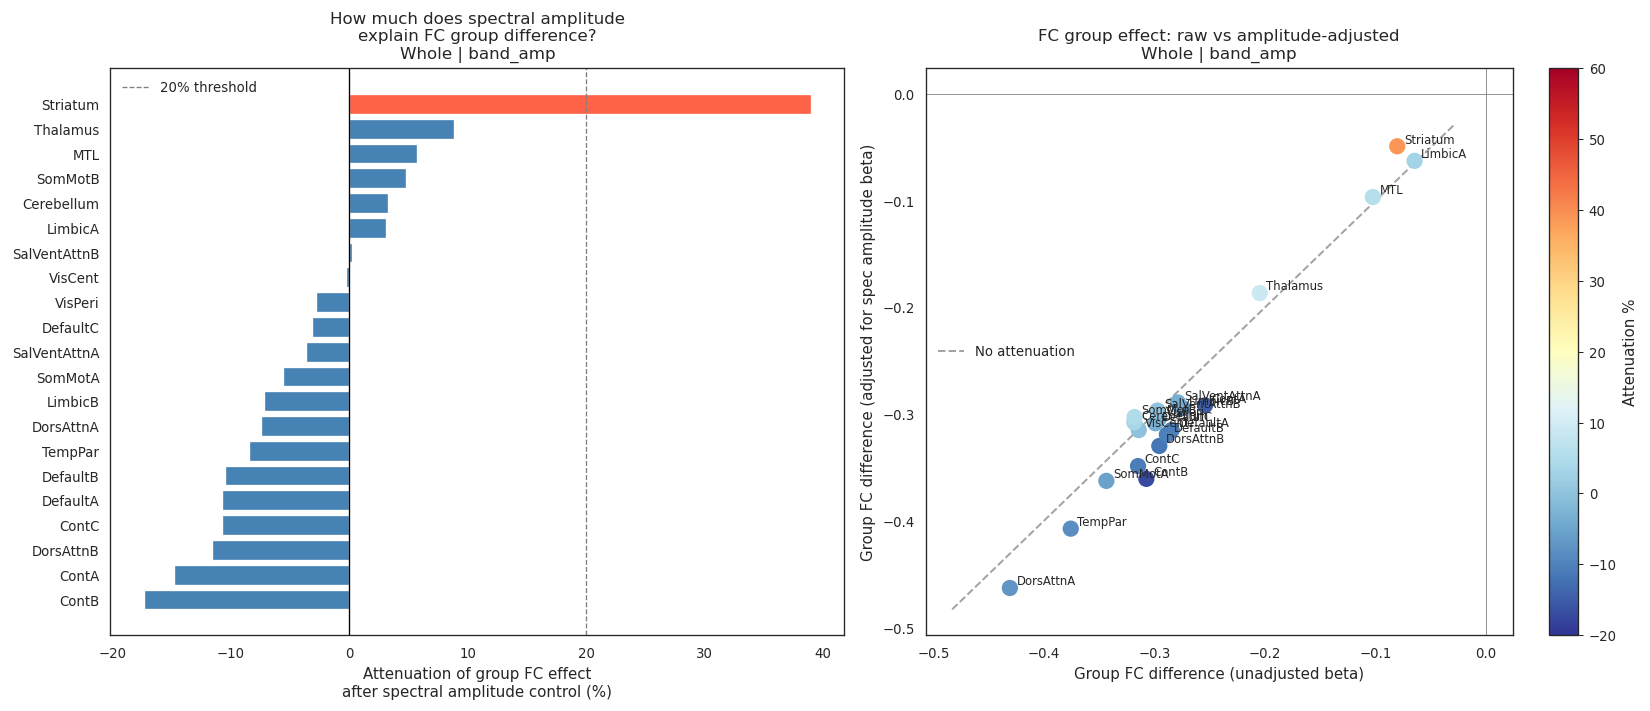

In [33]:
# Linearity checks — always run before fitting parametric models
for band in ["Slow-5", "Slow-4"]:
    plot_linearity_check(df_merged_amp, band=band, metric="band_amp")

# Global mixed model suite (all networks pooled, random intercepts per subject)
df_suite = run_mixed_suite_all(
    df_fc=df_fc,
    df_spec=df_spec,
    metrics=METRICS,
    bands=BANDS,
    control_total_amp=True,
    random_slopes=True,
)
print("\n=== Mixed-model suite results ===")
print_suite_results(df_suite)

# Residual diagnostics on the key Slow-5 interaction model
key = df_suite[
    (df_suite["metric"] == "band_amp") & (df_suite["band"] == "Slow-5")
]
if len(key) > 0:
    plot_residual_diagnostics(
        key.iloc[0]["m_interact"],
        title="band_amp | Slow-5 | interaction model",
    )

# Per-network analysis (independence holds — one row per subject per model)
for band in ["Slow-5", "Slow-4", "Slow-3", "Slow-2", "Whole"]:
    df_net = run_all_networks_parametric(
        df_merged_amp, band=band, metric="band_amp"
    )
    print_network_summary_table(df_net, band=band, metric="band_amp")
    plot_all_networks_summary(df_net, band=band, metric="band_amp")

In [34]:
# Sensitivity check: random slopes on Slow-5 band_amp only
df_merged_amp = build_merged_df(df_fc, df_spec, "band_amp")
row_rs = run_mixed_model_parametric(
    df_merged_amp,
    band="Slow-5",
    metric="band_amp",
    control_total_amp=True,
    random_slopes=True,
)
print(f"beta_group     = {row_rs['beta_group']:.4f}  p = {row_rs['p_group']:.4f}")
print(f"beta_group_adj = {row_rs['beta_group_adj']:.4f}  p = {row_rs['p_group_adj']:.4f}")
print(f"beta_interact  = {row_rs['beta_interaction']:.4f}  p = {row_rs['p_interaction']:.4f}")
print(f"Converged: {row_rs['m_interact'] is not None}")

beta_group     = -0.3018  p = 0.0283
beta_group_adj = -0.1250  p = 0.1201
beta_interact  = -0.1278  p = 0.1154
Converged: True
